# Llama 3.1 8B Instruct: Hugging Face vs TransformerBridge

Сравнение выполняется на **одном экземпляре одних и тех же весов**. Сначала измеряется прямой Hugging Face forward, затем тот же объект модели оборачивается в `TransformerBridge` и измеряется повторно.

Метрики:
- latency полного forward для batch size 1;
- throughput через `PerformanceEvaluator`;
- CUDA/CPU operator profile;
- агрегированный профиль компонентов Bridge (attention и MLP/MoE).

> После создания Bridge исходная HF-модель модифицирована in-place. Для повторного создания Bridge перезапустите kernel и выполните блокнот с начала.


In [1]:
# CUDA_VISIBLE_DEVICES нужно задавать до import torch.
import os
PHYSICAL_GPU = "3"
if PHYSICAL_GPU is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = PHYSICAL_GPU
os.environ.setdefault("HF_HUB_CACHE", "/glazkov-dev/.cache")
# os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


'/glazkov-dev/.cache'

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.data import TensorDataset
from transformers import AutoModelForCausalLM, AutoTokenizer

sys.path.insert(0, "/glazkov-dev")
from PerformanceEvaluator import PerformanceEvaluator
from transformer_lens.model_bridge import TransformerBridge
from transformer_lens.model_bridge.generalized_components.base import GeneralizedComponent

print("torch:", torch.__version__)
print("visible CUDA devices:", torch.cuda.device_count())
assert torch.cuda.is_available(), "Для этого benchmark требуется CUDA"
DEVICE = torch.device("cuda:0")
print("benchmark device:", torch.cuda.get_device_name(DEVICE))


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


torch: 2.10.0+cu128
visible CUDA devices: 1
benchmark device: NVIDIA A100-PCIE-40GB


## Конфигурация

Модель загружается напрямую через `AutoModelForCausalLM` в float16. `cuda:0` внутри процесса соответствует физической GPU из `PHYSICAL_GPU`.


In [3]:
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
DTYPE = torch.float16
SEQ_LEN = 512
BATCH_SIZE = 16
N_BATCHES = 8
THROUGHPUT_REPEATS = 3
PROFILE_STEPS = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

prompts = [
    "Explain mixture-of-experts routing in a transformer.",
    "Write a short comparison of quantization and pruning.",
    "Why does attention use a key-value cache during generation?",
    "Describe the difference between latency and throughput.",
] * (BATCH_SIZE * N_BATCHES // 4)
encoded = tokenizer(
    prompts,
    padding="max_length",
    truncation=True,
    max_length=SEQ_LEN,
    return_tensors="pt",
)
dataset = TensorDataset(encoded["input_ids"], encoded["attention_mask"])
print(encoded["input_ids"].shape)


torch.Size([128, 512])


## Адаптеры для PerformanceEvaluator

`PerformanceEvaluator` ожидает `model(tensor)` и вызывает `.to(device)`. Обёртка оставляет размещение модели без изменений и строит `attention_mask` из padding. Сырой `throughput_eval()` возвращает ms/sample; ниже значение переводится в samples/s.


In [4]:
class LLMForwardAdapter(nn.Module):
    def __init__(self, backend, pad_token_id: int, is_bridge: bool):
        super().__init__()
        self.backend = backend
        self.pad_token_id = pad_token_id
        self.is_bridge = is_bridge

    def to(self, *args, **kwargs):
        return self

    def forward(self, input_ids):
        attention_mask = input_ids.ne(self.pad_token_id).long()
        if self.is_bridge:
            return self.backend(
                input_ids,
                attention_mask=attention_mask,
                return_type="logits",
                use_cache=False,
                logits_to_keep=1,
            )
        return self.backend(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
            logits_to_keep=1,
            return_dict=True,
        ).logits


def benchmark_with_evaluator(adapter, label):
    evaluator = PerformanceEvaluator(
        adapter,
        data=dataset,
        device=DEVICE,
        batch_size=BATCH_SIZE,
        n_batches=N_BATCHES,
    )
    evaluator.warm_up_cuda(n_batches=3)
    latency_ms = evaluator.latency_eval()
    ms_per_sample = evaluator.throughput_eval(THROUGHPUT_REPEATS)
    result = {
        "backend": label,
        "latency_ms_mean": float(np.mean(latency_ms)),
        "latency_ms_std": float(np.std(latency_ms)),
        "ms_per_sample_mean": float(np.mean(ms_per_sample)),
        "ms_per_sample_std": float(np.std(ms_per_sample)),
        "throughput_samples_s": float(1000.0 / np.mean(ms_per_sample)),
    }
    return result, evaluator


## 1. Hugging Face

Модель загружается и сначала измеряется напрямую. Это baseline до in-place изменений, выполняемых Bridge.


In [5]:
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=DTYPE,
    device_map="cuda:0",
)
hf_model.eval()

print("model type:", type(hf_model).__name__)
print("parameter dtype:", next(hf_model.parameters()).dtype)

hf_memory_gib = torch.cuda.memory_allocated(DEVICE) / 2**30
hf_adapter = LLMForwardAdapter(hf_model, tokenizer.pad_token_id, is_bridge=False)
hf_result, hf_evaluator = benchmark_with_evaluator(
    hf_adapter, "Hugging Face"
)
pd.DataFrame([hf_result])


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

model type: LlamaForCausalLM
parameter dtype: torch.float16


warming: 8it [00:06,  1.27it/s]                       
throughput eval batches: 100%|██████████| 8/8 [00:18<00:00,  2.36s/batch]


,backend,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s
0,Hugging Face,58.994076,0.972611,49.144371,0.209855,20.34821


## 2. Hugging Face + TransformerBridge

Bridge оборачивает **тот же** объект HF-модели; второй экземпляр весов не загружается. Защитная проверка не позволяет случайно обернуть уже модифицированную модель второй раз.


In [6]:
already_bridged = [
    name for name, module in hf_model.named_modules()
    if isinstance(module, GeneralizedComponent)
]
assert not already_bridged, f"HF model уже обёрнута Bridge: {already_bridged[0]}"

bridge = TransformerBridge.boot_transformers(
    MODEL_ID,
    hf_model=hf_model,
    tokenizer=tokenizer,
    dtype=DTYPE,
)
bridge.eval()

bridge_memory_gib = torch.cuda.memory_allocated(DEVICE) / 2**30
bridge_adapter = LLMForwardAdapter(bridge, tokenizer.pad_token_id, is_bridge=True)
bridge_result, bridge_evaluator = benchmark_with_evaluator(
    bridge_adapter, "Hugging Face + TransformerBridge"
)
pd.DataFrame([bridge_result])


warming: 8it [00:06,  1.16it/s]                       
throughput eval batches: 100%|██████████| 8/8 [00:22<00:00,  2.77s/batch]


,backend,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s
0,Hugging Face + TransformerBridge,68.638688,0.948529,57.574928,0.343105,17.368671


## Детальный профиль Bridge

`record_function`-метки агрегируют время всех attention и MLP/MoE-компонентов без послойной таблицы. Профилирование запускается отдельно и не входит в основной benchmark.


In [7]:
def install_component_ranges(bridge_model):
    handles = []
    active_ranges = {}

    def add_range(module, label):
        def pre_hook(mod, args):
            ctx = record_function(label)
            ctx.__enter__()
            active_ranges[id(mod)] = ctx

        def post_hook(mod, args, output):
            active_ranges.pop(id(mod)).__exit__(None, None, None)

        handles.append(module.register_forward_pre_hook(pre_hook))
        handles.append(module.register_forward_hook(post_hook))

    for block in bridge_model.blocks:
        add_range(block.attn, "bridge_component::attention")
        add_range(block.mlp, "bridge_component::mlp_or_moe")
    return handles


profile_batch = encoded["input_ids"][:BATCH_SIZE].to(DEVICE)
for _ in range(2):
    with torch.inference_mode():
        bridge_adapter(profile_batch)
torch.cuda.synchronize()

range_handles = install_component_ranges(bridge)
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
) as bridge_profiler:
    for _ in range(PROFILE_STEPS):
        with record_function("bridge_model_inference"):
            with torch.inference_mode():
                bridge_adapter(profile_batch)
        torch.cuda.synchronize()

for handle in range_handles:
    handle.remove()

print(bridge_profiler.key_averages().table(sort_by="cpu_time_total", row_limit=25))
print(bridge_profiler.key_averages().table(sort_by="self_cuda_time_total", row_limit=25))


/glazkov-dev/.venv/lib/python3.10/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                 bridge_model_inference         2.33%      65.583ms        54.01%        1.523s     507.651ms       0.000us         0.00%        4.373s        1.458s           0 B           0 B           0 B    -218.89 G

In [8]:
def profiler_frame(prof):
    rows = []
    for event in prof.key_averages():
        rows.append({
            "name": event.key,
            "calls": event.count,
            "cpu_time_total_ms": event.cpu_time_total / 1000.0,
            "self_cpu_time_total_ms": event.self_cpu_time_total / 1000.0,
            "cuda_time_total_ms": getattr(event, "device_time_total", 0.0) / 1000.0,
            "self_cuda_time_total_ms": getattr(event, "self_device_time_total", 0.0) / 1000.0,
        })
    return pd.DataFrame(rows)


bridge_profile_df = profiler_frame(bridge_profiler)
component_profile = (
    bridge_profile_df[bridge_profile_df["name"].str.startswith("bridge_component::")]
    .sort_values("cuda_time_total_ms", ascending=False)
)
display(component_profile)

top_cuda_ops = bridge_profile_df.nlargest(20, "self_cuda_time_total_ms")
display(top_cuda_ops[["name", "calls", "self_cuda_time_total_ms", "cpu_time_total_ms"]])

trace_path = Path(
    "/glazkov-dev/LoRa-Transfer-Pruning/experiments/llama3_1_hf_bridge_trace.json"
)
bridge_profiler.export_chrome_trace(str(trace_path))
print("Chrome trace:", trace_path)


,name,calls,cpu_time_total_ms,self_cpu_time_total_ms,cuda_time_total_ms,self_cuda_time_total_ms
99,bridge_component::mlp_or_moe,96,80.131296,18.136370,2528.901459,0.000000
112,bridge_component::mlp_or_moe,96,0.000000,0.000000,1513.383145,1513.383145
78,bridge_component::attention,96,985.860328,58.042616,1372.978492,0.000000
89,bridge_component::attention,96,0.000000,0.000000,893.292401,893.292401


,name,calls,self_cuda_time_total_ms,cpu_time_total_ms
4,bridge_model_inference,3,2817.855104,0.000000
81,aten::mm,675,1787.726968,141.197449
117,Command Buffer Full,2061,1571.946833,1168.128908
112,bridge_component::mlp_or_moe,96,1513.383145,0.000000
113,ampere_fp16_s16816gemm_fp16_128x256_ldg8_f2f_s...,192,987.953544,0.000000
89,bridge_component::attention,96,893.292401,0.000000
116,void cutlass::Kernel2<cutlass_80_tensorop_f16_...,96,442.643879,0.000000
91,ampere_fp16_s16816gemm_fp16_256x128_ldg8_f2f_s...,192,286.262089,0.000000
62,aten::mul,1167,257.899852,127.781091
9,aten::copy_,1086,253.840281,262.968820


Chrome trace: /glazkov-dev/LoRa-Transfer-Pruning/experiments/llama3_1_hf_bridge_trace.json


## Сводная таблица и графики


,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s,latency_overhead_pct,throughput_change_pct,allocated_memory_gib
backend,,,,,,,,
Hugging Face,58.994,0.973,49.144,0.210,20.348,0.000,0.000,14.958
Hugging Face + TransformerBridge,68.639,0.949,57.575,0.343,17.369,16.348,-14.643,14.966


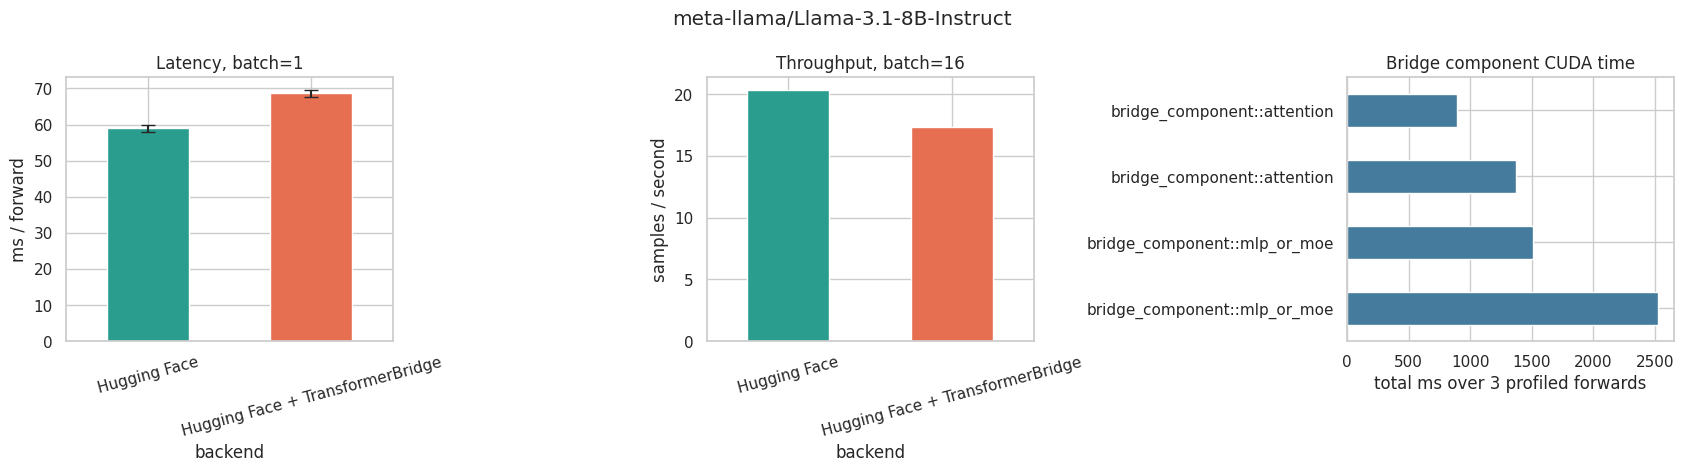

In [9]:
results = pd.DataFrame([hf_result, bridge_result]).set_index("backend")
baseline = "Hugging Face"
results["latency_overhead_pct"] = (
    results["latency_ms_mean"] / results.loc[baseline, "latency_ms_mean"] - 1
) * 100
results["throughput_change_pct"] = (
    results["throughput_samples_s"] / results.loc[baseline, "throughput_samples_s"] - 1
) * 100
results["allocated_memory_gib"] = [hf_memory_gib, bridge_memory_gib]
display(results.round(3))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
plt.suptitle(MODEL_ID)

results["latency_ms_mean"].plot.bar(
    ax=axes[0],
    yerr=results["latency_ms_std"],
    capsize=5,
    color=["#2a9d8f", "#e76f51"],
)
axes[0].set_title("Latency, batch=1")
axes[0].set_ylabel("ms / forward")
axes[0].tick_params(axis="x", rotation=15)

results["throughput_samples_s"].plot.bar(
    ax=axes[1], color=["#2a9d8f", "#e76f51"]
)
axes[1].set_title(f"Throughput, batch={BATCH_SIZE}")
axes[1].set_ylabel("samples / second")
axes[1].tick_params(axis="x", rotation=15)

if not component_profile.empty:
    component_profile.set_index("name")["cuda_time_total_ms"].plot.barh(
        ax=axes[2], color="#457b9d"
    )
axes[2].set_title("Bridge component CUDA time")
axes[2].set_xlabel(f"total ms over {PROFILE_STEPS} profiled forwards")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


/tmp/ipykernel_719016/3609168190.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


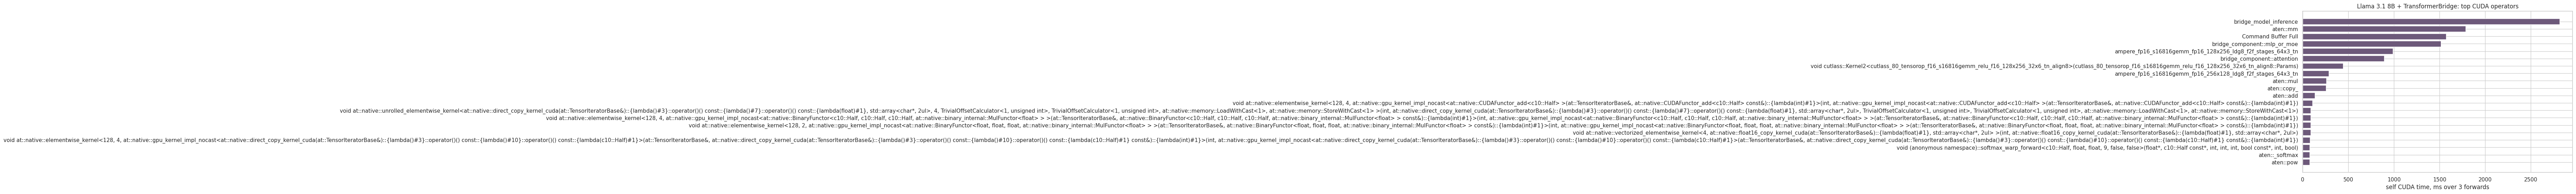

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_ops = top_cuda_ops.sort_values("self_cuda_time_total_ms")
ax.barh(plot_ops["name"], plot_ops["self_cuda_time_total_ms"], color="#6d597a")
ax.set_title("Llama 3.1 8B + TransformerBridge: top CUDA operators")
ax.set_xlabel(f"self CUDA time, ms over {PROFILE_STEPS} forwards")
plt.tight_layout()
plt.show()
